In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.graphics.tsaplots as tsaplot
import statsmodels.tsa.stattools as tsa
from statsmodels.tsa.statespace.tools import diff
import statsmodels.tsa.seasonal as seasonal
from statsmodels.tsa.api import VAR

In [2]:
'''
statsmodels.graphics.tsaplots: tsaplot 
- plot_acf, plot_pacf

statsmodels.tsa.stattools:
- acf, pacf
- adfuller
- grangercausalitytests(x, maxlag, addconst=True, verbose=None)

statsmodels.tsa.seasonal
- seasonal_decompose(ts, model='additive', period= /* your frequency here, e.g., 12 for monthly data */ )
seasonal.seasonal_decompose(df).plot()
plt.show()
- stl = STL(ts, seasonal= /* your seasonal period, e.g., 12 */) 
  result = stl.fit()

VAR Example:
# Assuming 'data' is a stationary pandas DataFrame
model = VAR(data)
# Select lag order based on AIC
lag_order = model.select_order(maxlags=10)
results = model.fit(lag_order.aic)
# Forecast next 5 steps
forecast = results.forecast(data.values[-lag_order.aic:], steps=5)

Log Returns:
df['log_return'] = np.log(df['Price'] / df['Price'].shift(1))
'''

"\nstatsmodels.graphics.tsaplots: tsaplot \n- plot_acf, plot_pacf\n\nstatsmodels.tsa.stattools:\n- acf, pacf\n- adfuller\n- grangercausalitytests(x, maxlag, addconst=True, verbose=None)\n\nstatsmodels.tsa.seasonal\n- seasonal_decompose(ts, model='additive', period= /* your frequency here, e.g., 12 for monthly data */ )\nseasonal.seasonal_decompose(df).plot()\nplt.show()\n- stl = STL(ts, seasonal= /* your seasonal period, e.g., 12 */) \n  result = stl.fit()\n\nVAR Example:\n# Assuming 'data' is a stationary pandas DataFrame\nmodel = VAR(data)\n# Select lag order based on AIC\nlag_order = model.select_order(maxlags=10)\nresults = model.fit(lag_order.aic)\n# Forecast next 5 steps\nforecast = results.forecast(data.values[-lag_order.aic:], steps=5)\n\nLog Returns:\ndf['log_return'] = np.log(df['Price'] / df['Price'].shift(1))\n"

### Load And Format Data

In [3]:
df = pd.read_csv(r"FIXED_collectible_market_index.csv")
econ = pd.read_csv(r'FIXED Economic Data.csv')

#ampi = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\AMPI USD Converted.xls")
#be = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\BE100 Index 1000 Initial Price.xls")
#pcgs = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\PCGS3000 Index Monthly 2026 Fixed.xls")
#magic = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\MtG Reserved List Monthly.xls")


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace = True)
df.rename(columns = {'0':'Price'}, inplace = True)

In [5]:
df = df[:-1] # match tail index with econ data

In [6]:
df.tail()

,Price
Date,
2025-08-01,57737.392866
2025-09-01,57158.479046
2025-10-01,56808.033790
2025-11-01,60010.457700
2025-12-01,58261.698202


In [7]:
econ.rename(columns = {'Unnamed: 0':'Date'}, inplace = True)
econ['Date'] = pd.to_datetime(econ['Date'])
econ.set_index('Date', inplace = True)
econ = econ.round(2)

In [8]:
econ.head()

,S&P500 Close,S&P500 Volume,CPI,GDP,Unemployment Rate,Fed Rate,10 Year Treasury Yield,Retail Sales,Customer Spending
Date,,,,,,,,,
1970-02-01,85.75,13440000.0,38.1,5300.65,4.2,8.98,7.24,NaN,634.0
1970-03-01,89.71,12270000.0,38.3,5300.65,4.4,7.76,7.07,NaN,632.3
1970-04-01,90.07,9810000.0,38.5,5308.16,4.6,8.10,7.39,NaN,636.0
1970-05-01,81.44,8290000.0,38.6,5308.16,4.8,7.95,7.91,NaN,642.4
1970-06-01,77.84,15020000.0,38.8,5308.16,4.9,7.61,7.84,NaN,646.3


In [9]:
econ.iloc[263] # index position 263 is where Retail Sales start

S&P500 Close              4.172600e+02
S&P500 Volume             2.075700e+08
CPI                       1.383000e+02
GDP                       1.023644e+04
Unemployment Rate         7.300000e+00
Fed Rate                  4.030000e+00
10 Year Treasury Yield    7.030000e+00
Retail Sales              1.591770e+05
Customer Spending         4.084700e+03
Name: 1992-01-01 00:00:00, dtype: float64

## Time Series Analysis of Collectibles Market

#### Time Series Decomposition

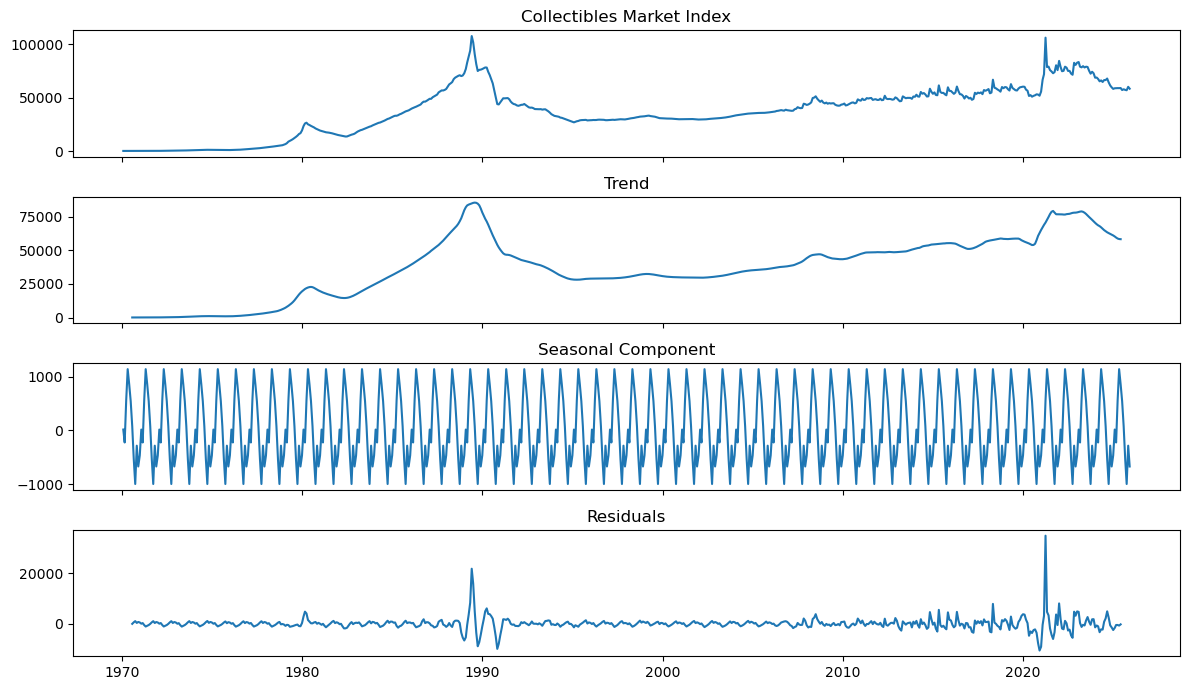

In [10]:
decomp = seasonal.seasonal_decompose(df)

fig, axes = plt.subplots(4, 1, figsize = (12, 7), sharex = True)

axes[0].plot(decomp.observed)
axes[0].set_title("Collectibles Market Index")

axes[1].plot(decomp.trend)
axes[1].set_title("Trend")

axes[2].plot(decomp.seasonal)
axes[2].set_title("Seasonal Component")

axes[3].plot(decomp.resid)
axes[3].set_title("Residuals")

plt.tight_layout()
plt.show()

- We can see by looking at the scales of the graphs that the trend is the majority of the contribution to the large variation and movement in our data
- We can also see that our data is non-stationary
- From this we can infer that non-constant mean is a major "source of non-stationarity" in our data

#### Observe ACF and PACF of Index

statsmodels.graphics.tsaplots: tsaplot 
- plot_acf, plot_pacf

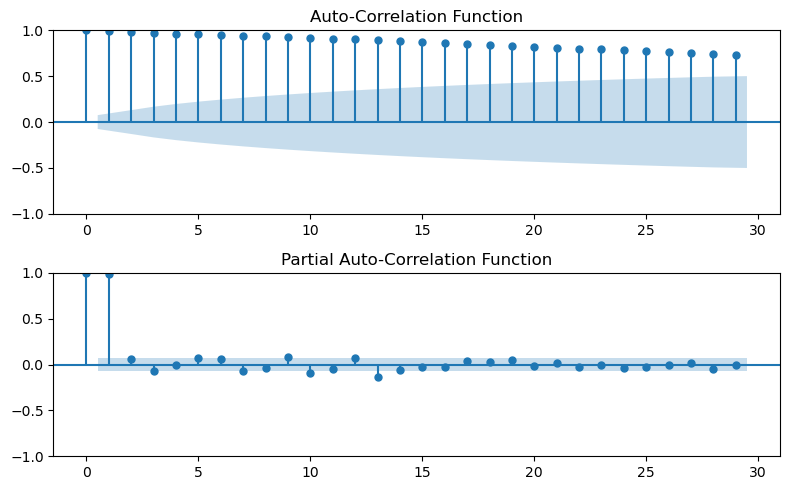

In [11]:
fig, axes = plt.subplots(2, 1, figsize = (8, 5))

tsaplot.plot_acf(df, ax = axes[0])
axes[0].set_title("Auto-Correlation Function")

tsaplot.plot_pacf(df, ax = axes[1])
axes[1].set_title("Partial Auto-Correlation Function")

plt.tight_layout()
plt.show()

From the ACF plot, we can see that our data is non-stationary

### Test Stationary for dfs

In [12]:
''' Confidence Intervals 99%, 95%, 90%
 {'1%': np.float64(-3.4403271946832645),
  '5%': np.float64(-2.8659424728408456),
  '10%': np.float64(-2.5691144817582985)}
'''

def test_stationary(array, k, string): # takes in time series and apply k differecing on the series
    diff_array = diff(array, k_diff = k)
    adfull = tsa.adfuller(diff_array)
    adf_pval = adfull[1]
    adf_stat = adfull[0]
    print(f'{string} Test: \n P-value: {adf_pval}, Test Statistic: {adf_stat}')

In [13]:
econ_list = econ.columns.tolist()
econ_list.remove('Retail Sales')
print(econ_list)

['S&P500 Close', 'S&P500 Volume', 'CPI', 'GDP', 'Unemployment Rate', 'Fed Rate', '10 Year Treasury Yield', 'Customer Spending']


In [14]:
test_stationary(df, 0, 'Collectibles Index')
for i in range(len(econ_list)):
    name = str(econ_list[i])
    test_series = econ[name]
    test_stationary(test_series, 0, name)

test_stationary(econ['Retail Sales'][263:], 0, 'Retail Sales')

Collectibles Index Test: 
 P-value: 0.271049361275558, Test Statistic: -2.0359187207621585
S&P500 Close Test: 
 P-value: 1.0, Test Statistic: 4.542535018542439
S&P500 Volume Test: 
 P-value: 0.9303280917202905, Test Statistic: -0.2649182463730925
CPI Test: 
 P-value: 0.9961329413300337, Test Statistic: 1.221776953138295
GDP Test: 
 P-value: 0.9987942689183034, Test Statistic: 2.1045069448376585
Unemployment Rate Test: 
 P-value: 0.01270770483435037, Test Statistic: -3.3520117734215003
Fed Rate Test: 
 P-value: 0.08464939475881827, Test Statistic: -2.6418659531266355
10 Year Treasury Yield Test: 
 P-value: 0.5545405937828224, Test Statistic: -1.4572555447743332
Customer Spending Test: 
 P-value: 1.0, Test Statistic: 4.622732392095804
Retail Sales Test: 
 P-value: 0.9976769729994381, Test Statistic: 1.5432635218516406


- P-value for stationary test is not in the 5% range for all series except Unemployment
- So we need to difference or log return all series as none of them are stationary
- **We will proceed with log return transformations for all series**

### Convert to Log Returns and Merge DataFrames for VAR Modelling

In [15]:
# Log return of collectibles index
df_log = pd.DataFrame()
df_log['Index Log Returns'] = np.log(df['Price'] / df['Price'].shift(1))

In [16]:
df_log.head()

,Index Log Returns
Date,
1970-02-01,NaN
1970-03-01,0.0
1970-04-01,0.0
1970-05-01,0.0
1970-06-01,0.0


In [17]:
# Log changes of economic data
econ_log = np.log(econ / econ.shift(1))

In [18]:
df_log = df_log[1:]
econ_log = econ_log[1:]

### Find Max Lag Using VAR Model

In [19]:
data = df_log.join(econ_log, how = 'outer')

In [20]:
data = data[264:]

In [21]:
data = data.asfreq('MS') 

In [22]:
data.tail()

,Index Log Returns,S&P500 Close,S&P500 Volume,CPI,GDP,Unemployment Rate,Fed Rate,10 Year Treasury Yield,Retail Sales,Customer Spending
Date,,,,,,,,,,
2025-08-01,0.012468,0.006433,-0.074095,0.003470,0.000000,0.000000,0.000000,-0.030060,0.005445,0.005530
2025-09-01,-0.010077,0.028062,-0.197251,0.002934,0.000000,0.022990,-0.025732,-0.033416,0.000672,0.003714
2025-10-01,-0.006150,0.045055,0.232788,0.001264,0.001627,0.011300,-0.031290,-0.014670,-0.001560,0.004015
2025-11-01,0.054841,0.020758,0.004589,0.001262,0.000000,0.011173,-0.052710,0.007362,0.005004,0.003437
2025-12-01,-0.029574,-0.005758,-0.287664,0.002980,0.000000,-0.022473,-0.042111,0.012151,-0.000001,0.004414


In [23]:
model = VAR(data)

lag_order = model.select_order(maxlags=12)
lag = lag_order.selected_orders['bic']

print(f'Max Lag 12: {lag_order.summary()}')

Max Lag 12:  VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -72.40      -72.30   3.592e-32      -72.36
1       -74.12     -73.01*   6.480e-33      -73.68
2       -74.88      -72.76   3.024e-33     -74.04*
3      -74.92*      -71.79  2.913e-33*      -73.68
4       -74.75      -70.62   3.450e-33      -73.11
5       -74.69      -69.55   3.694e-33      -72.65
6       -74.73      -68.57   3.614e-33      -72.29
7       -74.51      -67.34   4.560e-33      -71.67
8       -74.55      -66.38   4.443e-33      -71.31
9       -74.60      -65.42   4.331e-33      -70.97
10      -74.71      -64.52   4.023e-33      -70.67
11      -74.75      -63.54   4.040e-33      -70.31
12      -74.89      -62.67   3.687e-33      -70.05
--------------------------------------------------


In [24]:
results = model.fit(lag)

In [25]:
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Apr, 2026
Time:                     23:00:53
--------------------------------------------------------------------
No. of Equations:         10.0000    BIC:                   -73.2163
Nobs:                     405.000    HQIC:                  -73.8734
Log likelihood:           9409.82    FPE:                5.37440e-33
AIC:                     -74.3038    Det(Omega_mle):     4.11100e-33
--------------------------------------------------------------------
Results for equation Index Log Returns
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                            -0.000877         0.003136           -0.280           0.780
L1.Index Log Returns             -0.237443         0.048349           -4.911           0.000


In [26]:
'''
Model Diagnostics
'''
# 1. Stability
print(results.is_stable())
print('\n')

# 2. Serial correlation
print(results.test_whiteness(nlags=10))
print('\n')

# 3. Normality
print(results.test_normality())
print('\n')

# 4. ARCH effects
from statsmodels.stats.diagnostic import het_arch
for col in results.resid.columns:
    '''
    returns (LM_stat, LM_pvalue, F_stat, F_pvalue)
    LM_stat: Lagrange Multiplier test stat (measures strength of ARCH effect)
    LM_pvalue: Significance of LM test
    - F_stat and F_pvalue is alternative F test on finite sample
    '''
    print(het_arch(results.resid[col]))

True


<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 1643.456, critical value: 970.904>, p-value: 0.000>


<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: reject at 5% significance level. Test statistic: 55437.365, critical value: 31.410>, p-value: 0.000>


(np.float64(61.57038143589969), np.float64(1.8261334654734509e-09), 7.090859706226191, 2.9292496147810623e-10)
(np.float64(111.29572724507818), np.float64(2.9227624644069596e-19), 15.064122526990946, 1.0041755638054685e-22)
(np.float64(7.162027586008644), np.float64(0.7100651423501358), 0.7091153493582216, 0.7160320638920815)
(np.float64(43.23392941343809), np.float64(4.516203299672185e-06), 4.719565155069403, 2.201038775682149e-06)
(np.float64(146.01175424131142), np.float64(2.462001017986521e-26), 22.51853835823374

- If max lag is 12: then the lag selection is consistent with all the criterion selecting lag 12. I am suspicious of this as all the criterion measures suddenly decrease significantly at only 12 while before that the BIC and FPE were not consistently decreasing
- Max lag 10 has different results for different criterion, with BIC giving lag 1 and HQIC giving lag 2

- **Notable lagsof interest are 1, 2, and 3 for the granger test with a *maxlag* parameter of 12**

### Granger Causality Tests

##### Format Into N x 2 DataFrames for Granger Test

In [27]:
econ['Retail Sales'].iloc[263]

np.float64(159177.0)

In [28]:
df.iloc[263]

Price    42260.474756
Name: 1992-01-01 00:00:00, dtype: float64

In [29]:
print(econ_list)

['S&P500 Close', 'S&P500 Volume', 'CPI', 'GDP', 'Unemployment Rate', 'Fed Rate', '10 Year Treasury Yield', 'Customer Spending']


In [30]:
sp500_test = pd.merge(econ_log['S&P500 Close'], df_log, on='Date').copy() # change all to log returns then do granger
cpi_test = pd.merge(econ_log['CPI'], df_log, on='Date').copy()
gdp_test = pd.merge(econ_log['GDP'], df_log, on='Date').copy()
unemploy_test = pd.merge(econ_log['Unemployment Rate'], df_log, on='Date').copy()
fed_rate_test = pd.merge(econ_log['Fed Rate'], df_log, on='Date').copy()
tres_yield_test = pd.merge(econ_log['10 Year Treasury Yield'], df_log, on='Date').copy()

cust_spend_test = pd.merge(econ_log['Customer Spending'], df_log, on='Date').copy()
collectibles_cust_spend_test = pd.merge(df_log, econ_log['Customer Spending'], on='Date').copy()

retail_test = pd.merge(econ_log['Retail Sales'][263:], df_log[263:], on='Date').copy()
collectibles_retail_test = pd.merge(df_log[263:], econ_log['Retail Sales'][263:],  on='Date').copy()

##### Perform Granger Tests on Collectibles Index

In [31]:
print("Does Movement in the Collectibles Market Granger Cause the S&P500?:")
gc_sp500 = tsa.grangercausalitytests(sp500_test, maxlag = 12, addconst = True) # no notable pval less than 0.05

Does Movement in the Collectibles Market Granger Cause the S&P500?:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1116  , p=0.7384  , df_denom=666, df_num=1
ssr based chi2 test:   chi2=0.1121  , p=0.7377  , df=1
likelihood ratio test: chi2=0.1121  , p=0.7377  , df=1
parameter F test:         F=0.1116  , p=0.7384  , df_denom=666, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.6906  , p=0.5016  , df_denom=663, df_num=2
ssr based chi2 test:   chi2=1.3916  , p=0.4987  , df=2
likelihood ratio test: chi2=1.3901  , p=0.4990  , df=2
parameter F test:         F=0.6906  , p=0.5016  , df_denom=663, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.6325  , p=0.5942  , df_denom=660, df_num=3
ssr based chi2 test:   chi2=1.9177  , p=0.5897  , df=3
likelihood ratio test: chi2=1.9149  , p=0.5902  , df=3
parameter F test:         F=0.6325  , p=0.5942  , df_denom=660, df_num=3

Granger Causality
number 

In [32]:
print("Does Movement in the Collectibles Market Granger Cause Movement in CPI (Inflation)?:")
gc_cpi = tsa.grangercausalitytests(cpi_test, maxlag = 12, addconst = True) # pval less than 0.05 for all lags

Does Movement in the Collectibles Market Granger Cause Movement in CPI (Inflation)?:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.2026  , p=0.0130  , df_denom=666, df_num=1
ssr based chi2 test:   chi2=6.2306  , p=0.0126  , df=1
likelihood ratio test: chi2=6.2018  , p=0.0128  , df=1
parameter F test:         F=6.2026  , p=0.0130  , df_denom=666, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.9276  , p=0.0011  , df_denom=663, df_num=2
ssr based chi2 test:   chi2=13.9597 , p=0.0009  , df=2
likelihood ratio test: chi2=13.8159 , p=0.0010  , df=2
parameter F test:         F=6.9276  , p=0.0011  , df_denom=663, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.1304  , p=0.0065  , df_denom=660, df_num=3
ssr based chi2 test:   chi2=12.5226 , p=0.0058  , df=3
likelihood ratio test: chi2=12.4065 , p=0.0061  , df=3
parameter F test:         F=4.1304  , p=0.0065  , df_denom=660, df_num=3

Granger 

In [33]:
print("Does Movement in the Collectibles Market Granger Cause GDP?:")
gc_gdp = tsa.grangercausalitytests(gdp_test, maxlag = 12, addconst = True) # no notable pval less than 0.05

Does Movement in the Collectibles Market Granger Cause GDP?:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.8294  , p=0.3628  , df_denom=666, df_num=1
ssr based chi2 test:   chi2=0.8332  , p=0.3614  , df=1
likelihood ratio test: chi2=0.8326  , p=0.3615  , df=1
parameter F test:         F=0.8294  , p=0.3628  , df_denom=666, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.3110  , p=0.2703  , df_denom=663, df_num=2
ssr based chi2 test:   chi2=2.6417  , p=0.2669  , df=2
likelihood ratio test: chi2=2.6365  , p=0.2676  , df=2
parameter F test:         F=1.3110  , p=0.2703  , df_denom=663, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.5618  , p=0.6404  , df_denom=660, df_num=3
ssr based chi2 test:   chi2=1.7032  , p=0.6362  , df=3
likelihood ratio test: chi2=1.7010  , p=0.6367  , df=3
parameter F test:         F=0.5618  , p=0.6404  , df_denom=660, df_num=3

Granger Causality
number of lags

In [34]:
print("Does Movement in the Collectibles Market Granger Cause Unemployment?:")
gc_unemploy = tsa.grangercausalitytests(unemploy_test, maxlag = 12, addconst = True) # no notable pval less than 0.05

Does Movement in the Collectibles Market Granger Cause Unemployment?:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.3489  , p=0.1258  , df_denom=666, df_num=1
ssr based chi2 test:   chi2=2.3595  , p=0.1245  , df=1
likelihood ratio test: chi2=2.3554  , p=0.1249  , df=1
parameter F test:         F=2.3489  , p=0.1258  , df_denom=666, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.6834  , p=0.1865  , df_denom=663, df_num=2
ssr based chi2 test:   chi2=3.3921  , p=0.1834  , df=2
likelihood ratio test: chi2=3.3836  , p=0.1842  , df=2
parameter F test:         F=1.6834  , p=0.1865  , df_denom=663, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.2681  , p=0.2843  , df_denom=660, df_num=3
ssr based chi2 test:   chi2=3.8447  , p=0.2787  , df=3
likelihood ratio test: chi2=3.8337  , p=0.2800  , df=3
parameter F test:         F=1.2681  , p=0.2843  , df_denom=660, df_num=3

Granger Causality
numbe

In [35]:
print("Does Movement in the Collectibles Market Granger Cause Movement for Federal Fund Rates?:")
gc_fed = tsa.grangercausalitytests(fed_rate_test, maxlag = 12, addconst = True) # no notable pval less than 0.05

Does Movement in the Collectibles Market Granger Cause Movement for Federal Fund Rates?:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3723  , p=0.5420  , df_denom=666, df_num=1
ssr based chi2 test:   chi2=0.3740  , p=0.5408  , df=1
likelihood ratio test: chi2=0.3739  , p=0.5409  , df=1
parameter F test:         F=0.3723  , p=0.5420  , df_denom=666, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2868  , p=0.2768  , df_denom=663, df_num=2
ssr based chi2 test:   chi2=2.5931  , p=0.2735  , df=2
likelihood ratio test: chi2=2.5881  , p=0.2742  , df=2
parameter F test:         F=1.2868  , p=0.2768  , df_denom=663, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9332  , p=0.4242  , df_denom=660, df_num=3
ssr based chi2 test:   chi2=2.8292  , p=0.4187  , df=3
likelihood ratio test: chi2=2.8232  , p=0.4197  , df=3
parameter F test:         F=0.9332  , p=0.4242  , df_denom=660, df_num=3

Gran

In [36]:
print("Does Movement in the Collectibles Market Granger Cause Movement in 10 Year Treasury yield?:")
gc_tres = tsa.grangercausalitytests(tres_yield_test, maxlag = 12, addconst = True) # no notable pval less than 0.05

Does Movement in the Collectibles Market Granger Cause Movement in 10 Year Treasury yield?:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0169  , p=0.8965  , df_denom=666, df_num=1
ssr based chi2 test:   chi2=0.0170  , p=0.8962  , df=1
likelihood ratio test: chi2=0.0170  , p=0.8962  , df=1
parameter F test:         F=0.0169  , p=0.8965  , df_denom=666, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0086  , p=0.9914  , df_denom=663, df_num=2
ssr based chi2 test:   chi2=0.0174  , p=0.9913  , df=2
likelihood ratio test: chi2=0.0174  , p=0.9913  , df=2
parameter F test:         F=0.0086  , p=0.9914  , df_denom=663, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9132  , p=0.4341  , df_denom=660, df_num=3
ssr based chi2 test:   chi2=2.7686  , p=0.4287  , df=3
likelihood ratio test: chi2=2.7629  , p=0.4296  , df=3
parameter F test:         F=0.9132  , p=0.4341  , df_denom=660, df_num=3

G

In [37]:
print("Does Collectibles Market Granger Cause Consumer Spending:")
gc_spend = tsa.grangercausalitytests(cust_spend_test, maxlag = 12, addconst = True) # Lags 2 - 7 and 9 are significant with pval < 0.05
print("\n \n Does Consumer Spending Granger Cause Movement in the Collectibles Market")
gc_coll_spend = tsa.grangercausalitytests(collectibles_cust_spend_test, maxlag = 12, addconst = True) # pval less than 0.05 for all lags

Does Collectibles Market Granger Cause Consumer Spending:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.1439  , p=0.0767  , df_denom=666, df_num=1
ssr based chi2 test:   chi2=3.1580  , p=0.0756  , df=1
likelihood ratio test: chi2=3.1506  , p=0.0759  , df=1
parameter F test:         F=3.1439  , p=0.0767  , df_denom=666, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.8791  , p=0.0029  , df_denom=663, df_num=2
ssr based chi2 test:   chi2=11.8469 , p=0.0027  , df=2
likelihood ratio test: chi2=11.7430 , p=0.0028  , df=2
parameter F test:         F=5.8791  , p=0.0029  , df_denom=663, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.1661  , p=0.0062  , df_denom=660, df_num=3
ssr based chi2 test:   chi2=12.6309 , p=0.0055  , df=3
likelihood ratio test: chi2=12.5128 , p=0.0058  , df=3
parameter F test:         F=4.1661  , p=0.0062  , df_denom=660, df_num=3

Granger Causality
number of lags (n

In [38]:
print("Does Collectibles Market Granger Cause Retail Sales:")
gc_retail = tsa.grangercausalitytests(retail_test, maxlag = 12, addconst = True) # no notable pval less than 0.05
print("\n \n Does Retail Sales Granger Cause Movement in the Collectibles Market")
gc_coll_retail = tsa.grangercausalitytests(collectibles_retail_test, maxlag = 12, addconst = True) # pval less than 0.05 for all lags

Does Collectibles Market Granger Cause Retail Sales:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0221  , p=0.8818  , df_denom=403, df_num=1
ssr based chi2 test:   chi2=0.0223  , p=0.8813  , df=1
likelihood ratio test: chi2=0.0223  , p=0.8813  , df=1
parameter F test:         F=0.0221  , p=0.8818  , df_denom=403, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.5725  , p=0.2088  , df_denom=400, df_num=2
ssr based chi2 test:   chi2=3.1843  , p=0.2035  , df=2
likelihood ratio test: chi2=3.1719  , p=0.2048  , df=2
parameter F test:         F=1.5725  , p=0.2088  , df_denom=400, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3937  , p=0.2443  , df_denom=397, df_num=3
ssr based chi2 test:   chi2=4.2547  , p=0.2352  , df=3
likelihood ratio test: chi2=4.2324  , p=0.2374  , df=3
parameter F test:         F=1.3937  , p=0.2443  , df_denom=397, df_num=3

Granger Causality
number of lags (no zer

#### Results:
- Only significant p-values (< 0.05) were found for CPI, Customer Spending, and Retail Sales
- For **CPI, Consumer Spending $\rightarrow$ Collectibles Market, Retail Sales $\rightarrow$ Collectibles Market**: tests for all lags were found to be significant with p-value < 0.05
- For **Collectibles Market $\rightarrow$ Consumer Spending**: Lags 2 - 7 and 9 are significant with pval < 0.05
- All other tests were insignificant with p-values > 0.05

In [39]:
gc_list = [gc_sp500, gc_cpi, gc_gdp, gc_unemploy, gc_fed, gc_tres, gc_spend, gc_retail, gc_coll_spend, gc_coll_retail]
results = []

for test in gc_list:
    test_result = []
    for lag in test:
        f_stat, p_value, df_denom, df_num = test[lag][0]['ssr_ftest']
        test_result.append(p_value)

    results.append(test_result)

print(results)



[[np.float64(0.738388316428033), np.float64(0.5016417122986127), np.float64(0.5942104408968216), np.float64(0.12027226839980054), np.float64(0.1823751310784255), np.float64(0.21522004904344882), np.float64(0.291790854380063), np.float64(0.09390596319162847), np.float64(0.09782503023312578), np.float64(0.13687013023607447), np.float64(0.08636310260023826), np.float64(0.10605253904023156)], [np.float64(0.012998512840365451), np.float64(0.0010528839904622293), np.float64(0.0064662811569068425), np.float64(0.007926499411724141), np.float64(0.017884693743538356), np.float64(0.026548227670284023), np.float64(0.0013653045555412564), np.float64(0.0018811984785569058), np.float64(0.0009389442433179801), np.float64(0.0010277300522155688), np.float64(0.00034802611943699017), np.float64(0.002004508464813566)], [np.float64(0.36276861020009454), np.float64(0.2702593763097831), np.float64(0.6404012489744115), np.float64(0.49117580976948927), np.float64(0.5646517253439591), np.float64(0.60766617812357

In [40]:
col_names = ['S&P500', 'CPI', 'GDP', 'Unemployment Rate', 'Federal Fund Rate', '10 Year Treasury Yield', 'Consumer Spending', 'Retail Sales']
df = pd.DataFrame()

for i in range(len(col_names)):
    df[col_names[i]] = results[i]

In [41]:
df.head(20)

,S&P500,CPI,GDP,Unemployment Rate,Federal Fund Rate,10 Year Treasury Yield,Consumer Spending,Retail Sales
0,0.738388,0.012999,0.362769,0.125843,0.541964,0.896462,0.076670,0.881812
1,0.501642,0.001053,0.270259,0.186539,0.276828,0.991389,0.002945,0.208806
2,0.594210,0.006466,0.640401,0.284313,0.424208,0.434149,0.006157,0.244256
3,0.120272,0.007926,0.491176,0.421449,0.519586,0.617291,0.011290,0.385118
4,0.182375,0.017885,0.564652,0.546530,0.294862,0.736427,0.023305,0.362216
5,0.215220,0.026548,0.607666,0.622762,0.347416,0.209874,0.023416,0.481406
6,0.291791,0.001365,0.680213,0.721390,0.187503,0.293383,0.021881,0.569193
7,0.093906,0.001881,0.419176,0.606979,0.248615,0.342272,0.064977,0.433490
8,0.097825,0.000939,0.670863,0.742271,0.215083,0.308933,0.044178,0.418991
9,0.136870,0.001028,0.682067,0.815999,0.077647,0.374158,0.267192,0.633082


In [42]:
df2 = pd.DataFrame()

df2['Consumer Spending Granger Causes Collectibles Market'] = results[-2]
df2['Retail Sales Granger Causes Collectibles Market'] = results[-1]

In [43]:
df2.head(12)

,Consumer Spending Granger Causes Collectibles Market,Retail Sales Granger Causes Collectibles Market
0,1.432285e-05,9.340840e-05
1,5.768186e-05,1.930400e-04
2,3.746501e-05,4.301652e-05
3,1.275461e-04,1.711920e-04
4,2.484017e-04,4.054763e-04
5,2.643123e-04,1.604689e-04
6,3.820718e-04,3.677296e-04
7,1.979769e-06,7.794271e-07
8,4.209266e-06,8.858785e-08
9,1.835395e-05,2.596978e-08


In [44]:
df = df.round(4)
df2 = df2.round(5)

In [45]:
index = [i for i in range(1, 13)]

In [46]:
df['Lag'] = index
df2['Lag'] = index

df = df.set_index('Lag')
df2 = df2.set_index('Lag')

In [47]:
df.to_latex()

'\\begin{tabular}{lrrrrrrrr}\n\\toprule\n & S&P500 & CPI & GDP & Unemployment Rate & Federal Fund Rate & 10 Year Treasury Yield & Consumer Spending & Retail Sales \\\\\nLag &  &  &  &  &  &  &  &  \\\\\n\\midrule\n1 & 0.738400 & 0.013000 & 0.362800 & 0.125800 & 0.542000 & 0.896500 & 0.076700 & 0.881800 \\\\\n2 & 0.501600 & 0.001100 & 0.270300 & 0.186500 & 0.276800 & 0.991400 & 0.002900 & 0.208800 \\\\\n3 & 0.594200 & 0.006500 & 0.640400 & 0.284300 & 0.424200 & 0.434100 & 0.006200 & 0.244300 \\\\\n4 & 0.120300 & 0.007900 & 0.491200 & 0.421400 & 0.519600 & 0.617300 & 0.011300 & 0.385100 \\\\\n5 & 0.182400 & 0.017900 & 0.564700 & 0.546500 & 0.294900 & 0.736400 & 0.023300 & 0.362200 \\\\\n6 & 0.215200 & 0.026500 & 0.607700 & 0.622800 & 0.347400 & 0.209900 & 0.023400 & 0.481400 \\\\\n7 & 0.291800 & 0.001400 & 0.680200 & 0.721400 & 0.187500 & 0.293400 & 0.021900 & 0.569200 \\\\\n8 & 0.093900 & 0.001900 & 0.419200 & 0.607000 & 0.248600 & 0.342300 & 0.065000 & 0.433500 \\\\\n9 & 0.097800 & 0.0

In [48]:
df2.to_latex()

'\\begin{tabular}{lrr}\n\\toprule\n & Consumer Spending Granger Causes Collectibles Market & Retail Sales Granger Causes Collectibles Market \\\\\nLag &  &  \\\\\n\\midrule\n1 & 0.000010 & 0.000090 \\\\\n2 & 0.000060 & 0.000190 \\\\\n3 & 0.000040 & 0.000040 \\\\\n4 & 0.000130 & 0.000170 \\\\\n5 & 0.000250 & 0.000410 \\\\\n6 & 0.000260 & 0.000160 \\\\\n7 & 0.000380 & 0.000370 \\\\\n8 & 0.000000 & 0.000000 \\\\\n9 & 0.000000 & 0.000000 \\\\\n10 & 0.000020 & 0.000000 \\\\\n11 & 0.000030 & 0.000000 \\\\\n12 & 0.000000 & 0.000000 \\\\\n\\bottomrule\n\\end{tabular}\n'